In [3]:
import pandas as pd
import numpy as np

In [4]:
# Read Excel File as dataframe
df = pd.read_csv('Online_Retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Data Prep/Cleaning
We will process/transform the data so we can use it as input for the hmmlearn library. The goal is to format the observations as a 2d array of discrete observations [[1],[0],[1],....] for the hmmlearn library. We will groupby customerIDs and count their purchases (these will be our observation samples), and to make them discrete we will encode 0, 1-9, etc. purchases to 0, 1, ...

In [5]:
# All this is to just extract month_date and convert to month_0, month_1, etc.
df['Month_t'] = pd.to_datetime(df['InvoiceDate'])
base_date = pd.to_datetime('2010-12-01')
df['Month_t'] = (
    (df['Month_t'].dt.year - base_date.year) * 12 +
    (df['Month_t'].dt.month - base_date.month)
)

df['Month_t'] = df['Month_t'].apply(lambda x: f"Month_{x}")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month_t
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Month_0
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Month_0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,Month_0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Month_0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Month_0


In [6]:
temp = df.groupby(['CustomerID', 'Month_t']).count()
temp

InvoiceNo  StockCode  Description  Quantity  InvoiceDate  \
CustomerID Month_t                                                              
12346.0    Month_1           2          2            2         2            2   
12347.0    Month_0          31         31           31        31           31   
           Month_1          29         29           29        29           29   
           Month_10         47         47           47        47           47   
           Month_12         11         11           11        11           11   
...                        ...        ...          ...       ...          ...   
18283.0    Month_6         111        111          111       111          111   
           Month_7          57         57           57        57           57   
           Month_9          47         47           47        47           47   
18287.0    Month_10         41         41           41        41           41   
           Month_5          29         29           29        29           29   

                     UnitPrice  Country  
CustomerID Month_t                       
12346.0    Month_1           2        2  
12347.0    Month_0          31       31  
           Month_1          29       29  
           Month_10         47       47  
           Month_12         11       11  
...                        ...      ...  
18283.0    Month_6         111      111  
           Month_7          57       57  
           Month_9          47       47  
18287.0    Month_10         41       41  
           Month_5          29       29  

[13675 rows x 7 columns]

In [7]:
temp_reset = temp.reset_index()

In [8]:
per_customer_df = temp_reset[["CustomerID", "Month_t", "InvoiceNo"]]
per_customer_df.rename(columns={"InvoiceNo":"per_month_count"}, inplace=True)
per_customer_df.head()

wide_df = per_customer_df.pivot_table(
    index='CustomerID',
    columns='Month_t',
    values='per_month_count',
    aggfunc='sum',       
    fill_value=0         # fill missing with 0
).reset_index()

all_month_cols = [f"Month_{i}" for i in range(13)]
for col in all_month_cols:
    if col not in wide_df.columns:
        wide_df[col] = 0

wide_df = wide_df[['CustomerID'] + all_month_cols]
wide_df.columns.name = None
wide_df

C:\Users\danie\AppData\Local\Temp\ipykernel_27128\3591172049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  per_customer_df.rename(columns={"InvoiceNo":"per_month_count"}, inplace=True)


,CustomerID,Month_0,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,12346.0,0,2,0,0,0,0,0,0,0,0,0,0,0
1,12347.0,31,29,0,0,24,0,18,0,22,0,47,0,11
2,12348.0,17,6,0,0,5,0,0,0,0,3,0,0,0
3,12349.0,0,0,0,0,0,0,0,0,0,0,0,73,0
4,12350.0,0,0,17,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4367,18280.0,0,0,0,10,0,0,0,0,0,0,0,0,0
4368,18281.0,0,0,0,0,0,0,7,0,0,0,0,0,0
4369,18282.0,0,0,0,0,0,0,0,0,8,0,0,0,5
4370,18283.0,0,102,30,0,56,44,111,57,0,47,40,219,50


Finding quartiles to group number of purchases per month to associate active-ness

In [9]:
month_cols = [c for c in wide_df.columns if c.startswith("Month_")]
all_counts = wide_df[month_cols].values.flatten()
all_counts = all_counts[~np.isnan(all_counts)] #remove nan just in case

In [10]:
nonzero = all_counts[all_counts > 0]

q25 = np.quantile(nonzero, 0.25)
q50 = np.quantile(nonzero, 0.50)  
q75 = np.quantile(nonzero, 0.75)

print(q25, q75)

9.0 35.0


Emission Variables (Purchase Count Categories): <br>
  0: 0 purchases per month <br>
  1: 1-9 purchases per month <br>
  2: 10-35 purchases per month <br>
  3: 35+ purchases per month 

In [11]:
def emission_category(x, q25, q75):
    if x == 0:
        return 0     # Churn-level emission
    elif x <= q25:
        return 1     # Low purchasing
    elif x <= q75:
        return 2     # Medium purchasing
    else:
        return 3     # High purchasing
month_cols = ["Month_0", "Month_1", "Month_2", "Month_3", "Month_4", "Month_5","Month_6", "Month_7", "Month_8", "Month_9", "Month_10", "Month_11", "Month_12"]
nonzero_values = wide_df[month_cols].replace(0, np.nan).stack()   # flatten all months, drop zeros
q25 = nonzero_values.quantile(0.25)
q75 = nonzero_values.quantile(0.75)

print(f"Q25 (25th percentile of non-zero emissions): {q25:.2f}")
print(f"Q75 (75th percentile of non-zero emissions): {q75:.2f}")

category_df = wide_df[month_cols].apply(
    lambda col: col.map(lambda x: emission_category(x, q25, q75))
)

wide_df_category = wide_df.copy()
wide_df_category[month_cols] = category_df

wide_df_category = wide_df_category[['CustomerID'] + month_cols]

Q25 (25th percentile of non-zero emissions): 9.00
Q75 (75th percentile of non-zero emissions): 35.00


In [12]:
final_df = wide_df_category
final_df.head()

,CustomerID,Month_0,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,12346.0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,12347.0,2,2,0,0,2,0,2,0,2,0,3,0,2
2,12348.0,2,1,0,0,1,0,0,0,0,1,0,0,0
3,12349.0,0,0,0,0,0,0,0,0,0,0,0,3,0
4,12350.0,0,0,2,0,0,0,0,0,0,0,0,0,0


In [13]:
month_cols = [f'Month_{i}' for i in range(13)]  

sequence_list = final_df[month_cols].values.tolist()

formated_list_data = [[x] for row in final_df[month_cols].values.tolist() for x in row]

print(formated_list_data[:50])

[[0], [1], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [2], [2], [0], [0], [2], [0], [2], [0], [2], [0], [3], [0], [2], [2], [1], [0], [0], [1], [0], [0], [0], [0], [1], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]]


In [14]:
data = np.array(formated_list_data)

# EM Step and Viterbi
Now that we have the properly formatted data for hmmlearning, we can fit the model

In [15]:
from hmmlearn.hmm import CategoricalHMM
np.random.seed(67) #for reproducability

In [16]:
lengths = [13] * len(final_df)

In [17]:
model = CategoricalHMM(
    n_components=3, # n hidden states
    n_iter=100,      
    tol=1e-4 # convergence tolerance
)

data_reshaped = data.reshape(-1, 1)  # cuz shape has to be (n_observations, 1)


model.fit(data_reshaped, lengths)

,n_components,3
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,n_features,np.int64(4)
,algorithm,'viterbi'
,random_state,RandomState(M... 0x29268457B40
,n_iter,100
,tol,0.0001
,verbose,False
,params,'ste'


In [18]:
print("INITIAL STATE PROBABILITIES")
print("Values:", model.startprob_)
print("\nAs DataFrame:")
initial_df = pd.DataFrame(model.startprob_.reshape(-1, 1).T,
    columns=[f'State_{i}' for i in range(model.n_components)],
    index=['Probability']
)
print(initial_df)
print(f"\nSum: {model.startprob_.sum():.6f}")

# Transition Probability (transmat_)
print("\nTRANSITION PROBABILITY MATRIX")
transition_df = pd.DataFrame(
    model.transmat_,
    index=[f'From_State_{i}' for i in range(model.n_components)],
    columns=[f'To_State_{j}' for j in range(model.n_components)]
)
print(transition_df)

# Emission (emissionprob_)
print("\nEMISSION PROBABILITY MATRIX")
emission_df = pd.DataFrame(
    model.emissionprob_,
    index=[f'State_{i}' for i in range(model.n_components)],
    columns=[f'Emission_{j}' for j in range(model.emissionprob_.shape[1])]
)
print(emission_df)

initial_probs = model.startprob_
transition_probs = model.transmat_
emission_probs = model.emissionprob_


INITIAL STATE PROBABILITIES
Values: [0.30741207 0.59430187 0.09828606]

As DataFrame:
              State_0   State_1   State_2
Probability  0.307412  0.594302  0.098286

Sum: 1.000000

TRANSITION PROBABILITY MATRIX
              To_State_0  To_State_1  To_State_2
From_State_0    0.022024    0.975084    0.002892
From_State_1    0.112401    0.873890    0.013710
From_State_2    0.017815    0.001453    0.980732

EMISSION PROBABILITY MATRIX
         Emission_0  Emission_1  Emission_2  Emission_3
State_0    0.849315    0.081340    0.039451    0.029893
State_1    0.838061    0.048653    0.084524    0.028761
State_2    0.291298    0.114999    0.354072    0.239630


Are these results to be trusted? We see if EM converged to check

In [19]:
print("Converged:", model.monitor_.converged)
print("Final log-likelihood:", model.monitor_.history[-1])

Converged: True
Final log-likelihood: -42874.67845821362


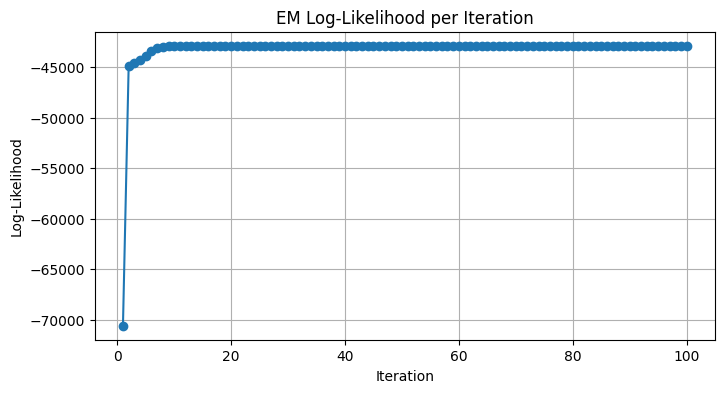

In [20]:
import matplotlib.pyplot as plt

history = model.monitor_.history

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker='o')
plt.title("EM Log-Likelihood per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.show()

We can see the EM algorithm converged and also improved the log-likelihood a lot over initial CPTs. So we can see it's somewhat valid to use EM on this dataset.

Now we try to interpret the results and assign each state a label (churn, at risk, active)

## Initial Probabilities

- **State_0**: 30.7% 
- **State_1**: 59.4%
- **State_2**: 9.8%

We can see at the beginning, most customers start in State_1, with a also quite a few in State_0. This reflects the customer distribution at Month_0, not necessarily their "true" initial state when they first became customers.


## Emission Probability Matrix

The emission matrix shows the probability of observing each purchase category given each hidden state:

### State_0:
- **84.9%** Emission_0 (0 purchases)
- **8.1%** Emission_1 (1-9 purchases)
- **3.9%** Emission_2 (10-35 purchases)
- **3.0%** Emission_3 (35+ purchases)

### State_1:
- **83.8%** Emission_0 (0 purchases)
- **4.9%** Emission_1 (1-9 purchases)
- **8.5%** Emission_2 (10-35 purchases)
- **2.9%** Emission_3 (35+ purchases)

### State_2:
- **29.1%** Emission_0 (0 purchases)
- **11.5%** Emission_1 (1-9 purchases)
- **35.4%** Emission_2 (10-35 purchases)
- **24.0%** Emission_3 (35+ purchases)

We can see that:
- State 1 and State 2 have a high probability of 0 purchases (80ish%). This makes sense because the data is from a a store that sells to wholesalers, so their customers mostly buy in bulk and only ocassionally. These would be inactive/semi-active states probably.
- **State_0** has the highest probability of zero purchases (29.1%), suggesting it represents the least active/inactive state. So state_0 is likely churned.
- **State_1** has the 2nd highest probability of zero purchases, so that might be the semi-active or at risk state.
- **State_2** has relatively high probabilities of a purchase at 71%

## Transition Probability Matrix

The transition probabilities shows how customers move between states from one month to the next:

### From State_0:
- **2.2%** to State_0
- **97.5%** to State_1 
- **0.3%** to State_2

State_0 is highly likely to go to State_1 and unlikely to stay as State_0.

### From State_1:
- **11.2%** to State_0
- **87.4%** to State_1
- **1.4%** to State_2

Highly likely to state at State_1 with some possibility to transition to State_0. (semi-active customers are likely to stay semi-active, with a higher probability to churn than become active again)

### From State_2:
- **1.8%** to State_0 
- **0.1%** to State_1 
- **98.1%** to State_2

Highly likely to state at State_2. Not likely to transition to any other state. (active customers are likely to stay active)


## Overall State Interpretation

Given the probabilities, we think each state represents:
- **State_0**: Churned state or inactive. Because it has highest probability of 0 purchases.

- **State_1**: At risk or semi-active. 2nd highest probability of zero purchases.

- **State_2**: Active. Lowest probability of 0 purchases at 24.0%

## Limitations

The main limitation is from the limited period of time recorded in the dataset. Because our dataset is only over a limited period of time, the initial state probabilities reflect the distribution at Month_0, not the true initial state when customers first joined. So the initial state probabilities might not generalize to completely new customers and their lifetime interaction with this company. 

This mean the probability for State_0 (Inactive) to State_2 or State_1 (Active or semi-Active) might be inflated because our dataset is filled with customers who eventually make a purchase in that period. While in reality, there could be customers who were active outside of our time period and are inactive during our time period. These customers are not captured in our dataset at all.

# Viterbi
Now we run the viterbi algorithm to find the most likely hidden states in each customer

In [21]:
logprob, hidden_states = model.decode(
    data_reshaped,
    lengths=lengths,
    algorithm="viterbi"
)

num_customers = len(final_df)
num_months = len(month_cols)

most_likely_states = hidden_states.reshape(num_customers, num_months)

viterbi_df = pd.DataFrame(
    most_likely_states,
    columns=month_cols
)
viterbi_df.insert(0, "CustomerID", final_df["CustomerID"].values)

viterbi_df.head()

,CustomerID,Month_0,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,12346.0,1,1,1,1,1,1,1,1,1,1,1,1,1
1,12347.0,2,2,2,2,2,2,2,2,2,2,2,2,2
2,12348.0,1,1,1,1,1,1,1,1,1,1,1,1,1
3,12349.0,1,1,1,1,1,1,1,1,1,1,1,1,1
4,12350.0,1,1,1,1,1,1,1,1,1,1,1,1,1


From here we can see the sequence of states for each customer. With these insights, the company will have more information when a customer is active, at-risk, or inactive. The company might use this data to strategize when to stockpile supplies to be ready for active customers, or to target advertisements/outreach to prevent inactivity.

---

# INCORPORATING MILESTONE 2 FEEDBACK

## HMM Sensitivity Analysis

Next, different modeling choices affects the Hidden Markov Model (HMM) performance when modeling customer churn states. We compare:

- Different numbers of hidden states
- Different binning methods for converting raw purchase counts into categorical emission symbols
- Model performance metric with Log-Likelihood
    
The goal is to identify the most stable and best-fitting model.

### Rebuilding the dataframe for different bin cutoff menthods

In [22]:
month_cols = [f"Month_{i}" for i in range(13)]


#### Percentile-Based Binning (as seen in the base case)

We convert raw monthly purchase counts into emission categories (0–3) using:
- 0 for zero purchases (churn-level activity)
- 1 for low purchases (≤ 25th percentile)
- 2 for medium purchases (≤ 75th percentile)
- 3 for high purchases (> 75th percentile)

In [23]:
def percentile_binning(df, month_cols):
    nonzero = df[month_cols].replace(0, np.nan).stack()
    q25 = nonzero.quantile(0.25)
    q75 = nonzero.quantile(0.75)

    def categorize(x):
        if x == 0:
            return 0
        elif x <= q25:
            return 1
        elif x <= q75:
            return 2
        else:
            return 3

    out = df.copy()
    out[month_cols] = df[month_cols].applymap(categorize)

    return out, (q25, q75)


#### Equal-Width Binning

Instead of percentiles, we take the min and max of non-zero purchase counts and evenly divide the interval into 3 boundaries (4 bins).
This gives an alternative binning strategy that we compare to percentile-based binning.

In [24]:
def equal_width_binning(df, month_cols):
    nonzero = df[month_cols].replace(0, np.nan).stack()

    mn, mx = nonzero.min(), nonzero.max()
    bins = np.linspace(mn, mx, 4)

    def categorize(x):
        if x == 0:
            return 0
        elif x <= bins[1]:
            return 1
        elif x <= bins[2]:
            return 2
        else:
            return 3

    out = df.copy()
    out[month_cols] = df[month_cols].applymap(categorize)

    return out, bins


In [25]:
def run_hmm(df_binned, n_states):
    # Flatten for hmmlearn
    data_list = df_binned[month_cols].values.tolist()
    flattened = np.array([[x] for row in data_list for x in row])

    lengths = [len(month_cols)] * len(df_binned)

    # Fit model
    model = CategoricalHMM(
        n_components=n_states,
        n_iter=100,
        tol=1e-4
    )

    model.fit(flattened, lengths)
    logL = model.monitor_.history[-1]

    return logL, model


#### Run the Comparison

This generates a dataframe with all results.

In [26]:
def evaluate_all_cases(base_df):
    results = []

    # 1. Percentile cutoff
    pct_df, pct_cutoffs = percentile_binning(base_df, month_cols)

    # 2. Equal-width cutoff
    eq_df, eq_bins = equal_width_binning(base_df, month_cols)

    cases = [
        ("3 States – Percentile (Base)", pct_df, 3),
        ("2 States – Percentile", pct_df, 2),
        ("4 States – Percentile", pct_df, 4),
        ("2 States – Equal Bin", eq_df, 2),
        ("3 States – Equal Bin", eq_df, 3),
        ("4 States – Equal Bin", eq_df, 4),
    ]

    for name, df_case, n_states in cases:
        logL, _ = run_hmm(df_case, n_states)
        results.append([name, n_states, logL])

    return pd.DataFrame(results, columns=["Case", "Hidden States", "Log-Likelihood"])


#### Rank the Models

We sort by log-likelihood (descending) because the best model has a likelihood closest to 0.

In [27]:
results_df = evaluate_all_cases(wide_df)
results_df

C:\Users\danie\AppData\Local\Temp\ipykernel_27128\1912592102.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out[month_cols] = df[month_cols].applymap(categorize)
C:\Users\danie\AppData\Local\Temp\ipykernel_27128\3589179142.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out[month_cols] = df[month_cols].applymap(categorize)


,Case,Hidden States,Log-Likelihood
0,3 States – Percentile (Base),3,-42871.889570
1,2 States – Percentile,2,-42881.811247
2,4 States – Percentile,4,-42815.197768
3,2 States – Equal Bin,2,-28892.256392
4,3 States – Equal Bin,3,-28887.757122
5,4 States – Equal Bin,4,-31151.793929


In [28]:
results_df_sorted = results_df.sort_values("Log-Likelihood", ascending=False)
results_df_sorted


,Case,Hidden States,Log-Likelihood
4,3 States – Equal Bin,3,-28887.757122
3,2 States – Equal Bin,2,-28892.256392
5,4 States – Equal Bin,4,-31151.793929
2,4 States – Percentile,4,-42815.197768
0,3 States – Percentile (Base),3,-42871.889570
1,2 States – Percentile,2,-42881.811247


After evaluating all the models, it seems the one with 3 hidden states binned equally yields the best log-likelihood.

In [ ]:
eq_df_best, eq_bin_edges = equal_width_binning(wide_df, month_cols)
best_logL, best_equal_model = run_hmm(eq_df_best, 3)

state_labels = [f"State_{i}" for i in range(best_equal_model.n_components)]
emission_labels = ["Zero", "Low", "Medium", "High"]

best_startprob = pd.Series(best_equal_model.startprob_, index=state_labels, name="Initial Probability")
best_transmat = pd.DataFrame(best_equal_model.transmat_, columns=state_labels, index=state_labels)
best_emissions = pd.DataFrame(best_equal_model.emissionprob_, columns=emission_labels, index=state_labels)

C:\Users\danie\AppData\Local\Temp\ipykernel_27128\3589179142.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out[month_cols] = df[month_cols].applymap(categorize)


(-28884.874450252606,
 array([1.00000000e+00, 6.33333333e+02, 1.26566667e+03, 1.89800000e+03]),
 State_0    0.847672
 State_1    0.107862
 State_2    0.044466
 Name: Initial Probability, dtype: float64,
           State_0   State_1   State_2
 State_0  0.165563  0.000289  0.834147
 State_1  0.018920  0.969505  0.011575
 State_2  0.457239  0.022426  0.520336,
              Zero       Low         Medium           High
 State_0  0.840535  0.159465  6.831293e-266  7.555262e-278
 State_1  0.283709  0.714543   1.281841e-03   4.661242e-04
 State_2  0.846253  0.153747  2.208622e-244  3.177808e-309)

In [31]:
print("BIN EDGES")
print(eq_bin_edges)

print("\nINITIAL DISTRIBUTION")
print(best_startprob)

print("\nTRANSITION PROBS")
print(best_transmat)

print("\nEMISSION PROBS")
print(best_emissions)

BIN EDGES
[1.00000000e+00 6.33333333e+02 1.26566667e+03 1.89800000e+03]

INITIAL DISTRIBUTION
State_0    0.847672
State_1    0.107862
State_2    0.044466
Name: Initial Probability, dtype: float64

TRANSITION PROBS
          State_0   State_1   State_2
State_0  0.165563  0.000289  0.834147
State_1  0.018920  0.969505  0.011575
State_2  0.457239  0.022426  0.520336

EMISSION PROBS
             Zero       Low         Medium           High
State_0  0.840535  0.159465  6.831293e-266  7.555262e-278
State_1  0.283709  0.714543   1.281841e-03   4.661242e-04
State_2  0.846253  0.153747  2.208622e-244  3.177808e-309


### Interpretation of the States

**State_0: Churn/Inactivity**. Because the initial probability of 0.85 and emission probability `P(Zero | State_0) = 0.84` show most customers start here and rarely transact. Transition matrix indicates a 0.83 chance of leaping directly to State_2 and almost zero flow to State_1, so the few reactivations skip the “low” state altogether. Such behavior matches dormant accounts that occasionally return with a spike. They spend most months with zero purchases and only reactivate in bursts.

**State_1: Low purchasers**. Because emission `P(Low | State_1) = 0.71` (with only 0.28 zero) and an extremely high self-transition `P(State_1 → State_1) = 0.97` reflect consistent, low-volume activity. Customers in this state keep buying small amounts month after month, rarely churning (only 2% move to State_0) and rarely upgrading to the bursty State_2 (1%).

**State_2 – Reactivated**. Half of the customers in this state churn right back to State_0 (0.46), only 2% drift into State_1, and the rest (0.52) linger briefly. Emission probabilities still favor zero purchases (0.85 zero vs 0.15 low) because equal-width bins make the high bin unused, meaning the state captures the immediate aftermath of a reactivation rather than sustained high spend. This "burst' state probably represents customers who just returned after inactivity—they spike out of State_0, but without reinforcement they mostly lapse again. It is distinct from State_1 because it lacks the stable low-frequency pattern and shows rapid churn-back dynamics.

# Running viterbi on the best model for the first 5 customers

In [ ]:
first5 = eq_df_best.head(5)
first5_obs = first5[month_cols].values.reshape(-1, 1)
first5_lengths = [len(month_cols)] * len(first5)

first5_logprob, first5_states = best_equal_model.decode(
    first5_obs,
    lengths=first5_lengths,
    algorithm="viterbi"
)

first5_viterbi = pd.DataFrame(
    first5_states.reshape(len(first5), len(month_cols)),
    columns=month_cols
)
first5_viterbi.insert(0, "CustomerID", first5["CustomerID"].values)

print("log prob: ", first5_logprob)
first5_viterbi

log prob:  -56.353124103554016


,CustomerID,Month_0,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,12346.0,0,2,0,2,2,0,2,0,2,0,2,0,2
1,12347.0,1,1,1,1,1,1,1,1,1,1,1,1,1
2,12348.0,0,2,0,2,0,2,0,2,2,0,2,0,2
3,12349.0,0,2,0,2,0,2,2,0,2,0,2,0,2
4,12350.0,0,2,0,2,0,2,0,2,0,2,0,2,2


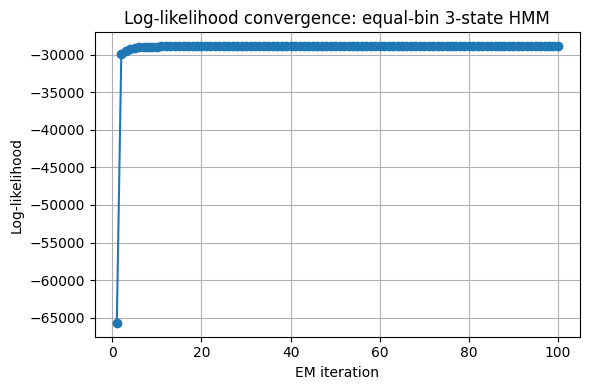

In [40]:
# Plot log-likelihood convergence

ll_history = best_equal_model.monitor_.history

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(ll_history) + 1), ll_history, marker="o")
plt.xlabel("EM iteration")
plt.ylabel("Log-likelihood")
plt.title("Log-likelihood convergence: equal-bin 3-state HMM")
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
#for latex
latex_table = first5_viterbi.to_latex(index=False, caption="Viterbi States for First Five Customers", label="tab:first5_viterbi")
print(latex_table)

latex_results = results_df_sorted.to_latex(
    index=False,
    caption="HMM model comparison with different numbers of states and binning methods.",
    label="tab:hmm_model_comparison",
    float_format="%.2f"
)
print(latex_results)

latex_init = best_startprob.to_frame().to_latex(
    header=True,
    caption="Initial state distribution for the best equal-bin 3-state HMM.",
    label="tab:hmm_init_equal3",
    float_format="%.4f"
)
print(latex_init)

latex_trans = best_transmat.to_latex(
    caption="State transition matrix for the best equal-bin 3-state HMM.",
    label="tab:hmm_trans_equal3",
    float_format="%.4f"
)
print(latex_trans)

latex_emit = best_emissions.to_latex(
    caption="Emission probabilities (Zero, Low, Medium, High) for the best equal-bin 3-state HMM.",
    label="tab:hmm_emit_equal3",
    float_format="%.4f"
)
print(latex_emit)


\begin{table}
\caption{Viterbi States for First Five Customers}
\label{tab:first5_viterbi}
\begin{tabular}{rrrrrrrrrrrrrr}
\toprule
CustomerID & Month_0 & Month_1 & Month_2 & Month_3 & Month_4 & Month_5 & Month_6 & Month_7 & Month_8 & Month_9 & Month_10 & Month_11 & Month_12 \\
\midrule
12346.000000 & 0 & 2 & 0 & 2 & 2 & 0 & 2 & 0 & 2 & 0 & 2 & 0 & 2 \\
12347.000000 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 \\
12348.000000 & 0 & 2 & 0 & 2 & 0 & 2 & 0 & 2 & 2 & 0 & 2 & 0 & 2 \\
12349.000000 & 0 & 2 & 0 & 2 & 0 & 2 & 2 & 0 & 2 & 0 & 2 & 0 & 2 \\
12350.000000 & 0 & 2 & 0 & 2 & 0 & 2 & 0 & 2 & 0 & 2 & 0 & 2 & 2 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{HMM model comparison with different numbers of states and binning methods.}
\label{tab:hmm_model_comparison}
\begin{tabular}{lrr}
\toprule
Case & Hidden States & Log-Likelihood \\
\midrule
3 States – Equal Bin & 3 & -28887.76 \\
2 States – Equal Bin & 2 & -28892.26 \\
4 States – Equal Bin & 4 & -31151.79 \\
4